# Phần 4: Tiền xử lý dữ liệu chuỗi thời gian
## Bước 1: Khởi tạo & Phân tích khám phá (EDA)

Notebook này thực hiện các yêu cầu phân tích khám phá ban đầu cho tập dữ liệu chuỗi thời gian. 

Tập dữ liệu được chọn là [`energy_dataset.csv`](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather/?select=energy_dataset.csv) về Điện năng ở Tây Ban Nha với tần suất theo giờ, kéo dài từ 2015 đến 2019. 

Tập trung vào biến `total load actual` (tổng tải thực tế) làm mục tiêu phân tích, vì biến này phản ánh trực tiếp chu kỳ nhu cầu tiêu thụ điện năng tổng hợp của nền kinh tế.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Cấu hình chuẩn cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14

In [2]:
# Đọc dữ liệu và parse cột thời gian
df = pd.read_csv('../data/raw/P4_energy_dataset.csv', parse_dates=['time'])

# Đặt 'time' làm index và chuẩn hóa múi giờ thành UTC để tránh lỗi lệch giờ
df = df.set_index('time')
df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()

# Chọn biến mục tiêu cho quá trình EDA 
target_col = 'total load actual'
ts_raw = df[target_col]

ts_raw.head()

time
2014-12-31 23:00:00+00:00    25385.0
2015-01-01 00:00:00+00:00    24382.0
2015-01-01 01:00:00+00:00    22734.0
2015-01-01 02:00:00+00:00    21286.0
2015-01-01 03:00:00+00:00    20264.0
Name: total load actual, dtype: float64

In [3]:
# Thống kê missing values trước khi drop để biện minh quyết định tiền xử lý cho EDA
total_count = ts_raw.shape[0]
missing_count = ts_raw.isna().sum()
valid_count = ts_raw.notna().sum()
missing_pct = (missing_count / total_count) * 100

print(f"Tổng số quan sát: {total_count:,}")
print(f"Số giá trị hợp lệ: {valid_count:,}")
print(f"Số giá trị thiếu (NA): {missing_count:,}")
print(f"Tỷ lệ thiếu: {missing_pct:.3f}%")

Tổng số quan sát: 35,064
Số giá trị hợp lệ: 35,028
Số giá trị thiếu (NA): 36
Tỷ lệ thiếu: 0.103%


> Qua kiểm tra, biến `total load actual` chỉ có **36** giá trị thiếu trên tổng số hơn **35.000** dòng (chiếm tỉ lệ cực kỳ nhỏ, xấp xỉ **0.1%**). Với cơ cấu dữ liệu theo giờ và tỉ lệ thiếu không đáng kể này, việc tạm thời loại bỏ các dòng NA ở bước EDA sẽ không làm méo mó cấu trúc chu kỳ hay sai lệch phân phối tổng thể của toàn bộ chuỗi.

In [4]:
# Drop tạm thời cho trực quan hóa EDA
ts = ts_raw.dropna()
ts.head()

time
2014-12-31 23:00:00+00:00    25385.0
2015-01-01 00:00:00+00:00    24382.0
2015-01-01 01:00:00+00:00    22734.0
2015-01-01 02:00:00+00:00    21286.0
2015-01-01 03:00:00+00:00    20264.0
Name: total load actual, dtype: float64

In [5]:
ts.describe()

count    35028.000000
mean     28696.939905
std       4574.987950
min      18041.000000
25%      24807.750000
50%      28901.000000
75%      32192.000000
max      41015.000000
Name: total load actual, dtype: float64

### a) Vẽ time plot và xác định thành phần chuỗi
Vẽ biểu đồ chuỗi thời gian để nhận diện bằng mắt các thành phần: xu hướng (trend), mùa vụ (seasonality) và nhiễu (noise).

#### Time plot cho toàn bộ giai đoạn 2015-2019:

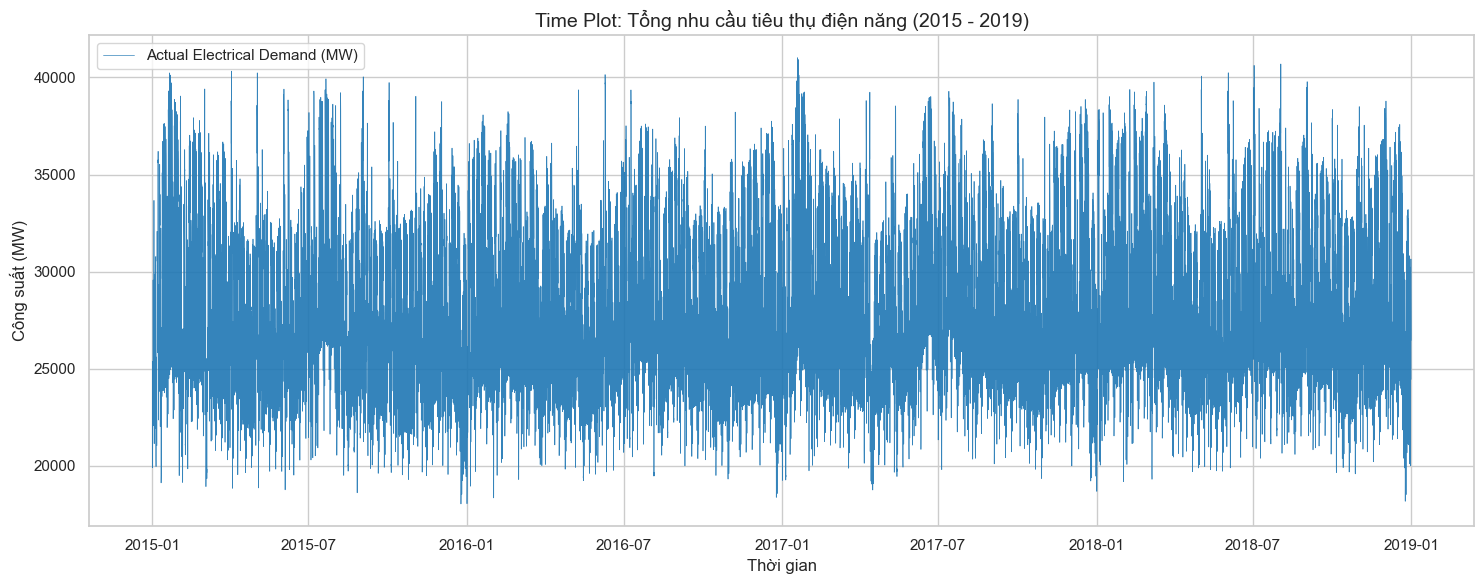

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(ts.index, ts.values, label='Actual Electrical Demand (MW)', color='#1f77b4', linewidth=0.5, alpha=0.9)
plt.title('Time Plot: Tổng nhu cầu tiêu thụ điện năng (2015 - 2019)')
plt.xlabel('Thời gian')
plt.ylabel('Công suất (MW)')
plt.legend()
plt.tight_layout()
plt.show()

#### Time plot cho tuần đầu tiên (7 ngày đầu tiên) của năm 2015 để thấy rõ hơn các chu kỳ ngắn hạn:

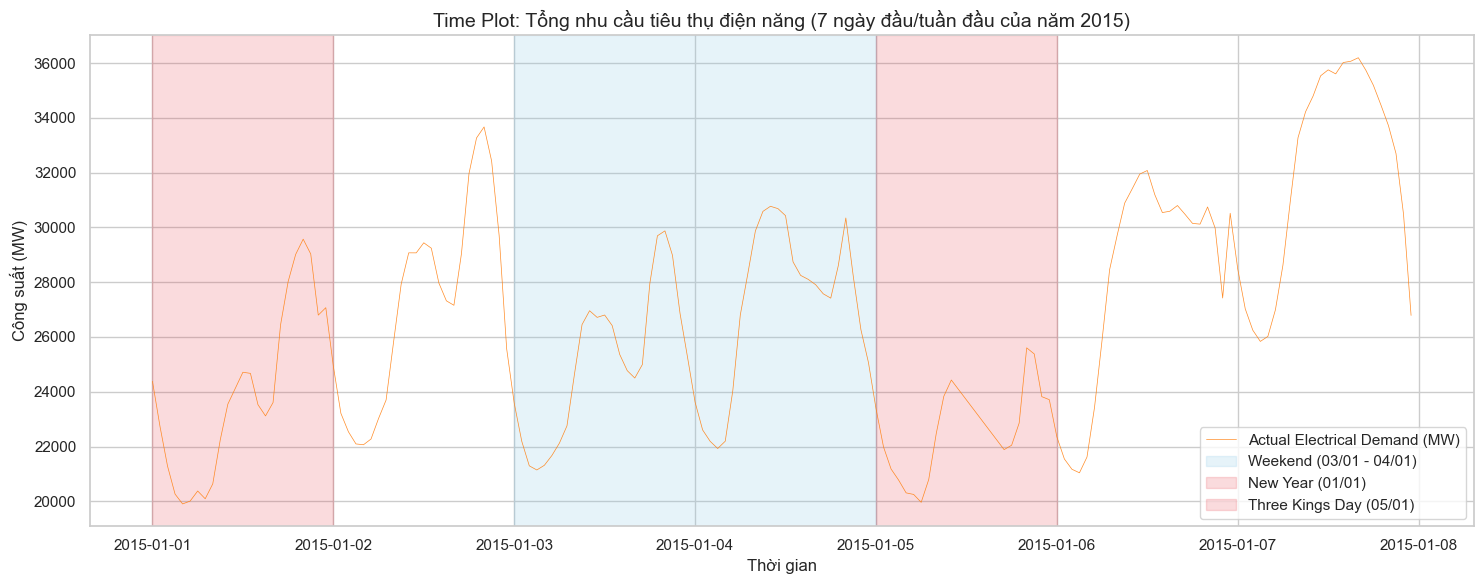

In [7]:
# Time plot trong tuần đầu tiên của năm 2015 để thấy rõ hơn các chu kỳ ngắn hạn
ts_first_week_2015 = ts['2015-01-01':'2015-01-07']

plt.figure(figsize=(15, 6))
plt.plot(
    ts_first_week_2015.index,
    ts_first_week_2015.values,
    label='Actual Electrical Demand (MW)',
    color='#ff7f0e',
    linewidth=0.5,
    alpha=0.9
)

ax = plt.gca()

# Highlight vùng cuối tuần (03/01 - 04/01)
weekend_start = pd.Timestamp('2015-01-03 00:00:00', tz='UTC')
weekend_end = pd.Timestamp('2015-01-05 00:00:00', tz='UTC')
ax.axvspan(weekend_start, weekend_end, color='#8ecae6', alpha=0.22, label='Weekend (03/01 - 04/01)')

# Highlight ngày lễ (01/01 và 05/01)
holiday_ranges = [
    (pd.Timestamp('2015-01-01 00:00:00', tz='UTC'), pd.Timestamp('2015-01-02 00:00:00', tz='UTC'), 'New Year (01/01)'),
    (pd.Timestamp('2015-01-05 00:00:00', tz='UTC'), pd.Timestamp('2015-01-06 00:00:00', tz='UTC'), 'Three Kings Day (05/01)')
]
for start, end, holiday_label in holiday_ranges:
    ax.axvspan(start, end, color='#e63946', alpha=0.18, label=holiday_label)

# Loại bỏ legend trùng nhãn do nhiều lần axvspan
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

plt.title('Time Plot: Tổng nhu cầu tiêu thụ điện năng (7 ngày đầu/tuần đầu của năm 2015)')
plt.xlabel('Thời gian')
plt.ylabel('Công suất (MW)')
plt.legend(unique.values(), unique.keys())
plt.tight_layout()
plt.show()

#### Nhận xét phân tích Time Plot

Dựa trên quan sát trực quan từ biểu đồ `total load actual` toàn bộ thời gian (2015 - 2019) và được đối chiếu chi tiết qua biểu đồ của tuần đầu tiên năm 2015, ta có thể đánh giá các thành phần cấu trúc của chuỗi như sau:

**1. Xu hướng (Trend):** Chuỗi thời gian không bộc lộ xu hướng tăng trưởng hay suy thoái dài hạn. Dữ liệu dao động ngang và duy trì sự ổn định quanh mức trung bình (xấp xỉ 28.700 MW), nằm trong biên độ từ 18.000 MW đến 41.000 MW. Điều này phản ánh tổng phụ tải vĩ mô của hệ thống đang ở trạng thái tương đối bão hòa.

**2. Tính mùa vụ (Seasonality):**
  * *Chu kỳ vĩ mô (hàng năm):* Đường bao dữ liệu tổng thể uốn lượn lặp lại theo từng năm, cho thấy sự ảnh hưởng mạnh mẽ của yếu tố khí hậu lên nhu cầu tiêu thụ điện (ví dụ: tăng cao vào mùa làm mát hoặc sưởi ấm).
  * *Chu kỳ vi mô (ngày & tuần):* Khi nội suy vào khung thời gian 7 ngày đầu năm 2015, tính mùa vụ vi mô hiện ra rất rõ nét:
    * **Chu kỳ ngày:** Mỗi ngày duy trì một mô hình dao động nhịp nhàng, chạm đáy vào các giờ rạng sáng (khi hoạt động sinh hoạt/sản xuất thấp nhất) và đạt đỉnh vào khung giờ làm việc ban ngày hoặc sinh hoạt buổi tối.
    * **Chu kỳ tuần:** Có sự phân hóa rõ rệt về biên độ tiêu thụ giữa ngày làm việc thông thường (06/01 - 07/01) với mức tải đỉnh đạt 34.000 - 36.000 MW, cao hơn hẳn so với ngày nghỉ cuối tuần (03/01 - 04/01) với mức tải đỉnh chỉ dao động quanh 28.000 - 30.000 MW.
  
**3. Nhiễu và Hiệu ứng ngày lễ (Noise & Holiday Effects):** Nhìn vào các vùng được tô màu trên biểu đồ tuần đầu tiên, ta có một minh chứng trực quan cho yếu tố bất thường. Ngày 01/01 (Tết Dương lịch) dù rơi vào giữa tuần nhưng mức tiêu thụ sụt giảm mạnh. Đặc biệt, ngày 05/01 (được highlight) lại có mức tải đỉnh thấp nhất, chạm đáy quanh mốc 20.000 MW. Sự sụt giảm bất thường này trùng khớp với ngày lễ Epiphany (Ba Vua) tại Tây Ban Nha. Điều này xác nhận các điểm rơi đột ngột trên biểu đồ tổng thể chính là "hiệu ứng ngày lễ" chứ không đơn thuần là nhiễu ngẫu nhiên.

**4. Đánh giá tính dừng sơ bộ:** Mặc dù phương sai tương đối đồng đều (nhìn từ biểu đồ tuần đâu 2015) và không có xu hướng dài hạn, nhưng sẽ có những tính mùa vụ lồng ghép phức tạp (năm, tuần, ngày) khiến mean của chuỗi thay đổi liên tục theo thời gian. Do đó, có thể nói đây là **chuỗi không dừng (non-stationary)**

### b) Phân tích tương quan (ACF & PACF)
Vẽ hàm tự tương quan (ACF) và tự tương quan riêng phần (PACF) với lag tối đa được tính toán cụ thể dựa trên số lượng mẫu theo quy định.

Công thức lag tối đa: $\min(10 \log_{10} n, n/5)$

Số quan sát (n): 35028
Lag tối đa được tính toán: 45


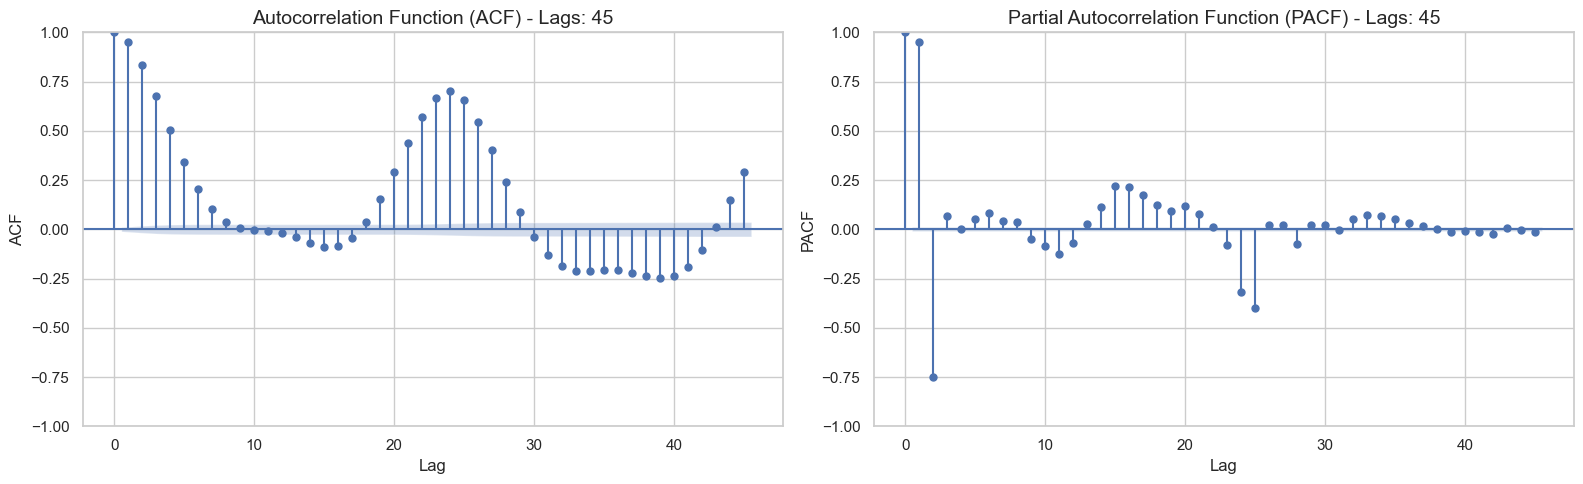

In [8]:
n = len(ts)
max_lag = int(np.min([10 * np.log10(n), n / 5]))
print(f"Số quan sát (n): {n}")
print(f"Lag tối đa được tính toán: {max_lag}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ ACF
plot_acf(ts, lags=max_lag, ax=axes[0], alpha=0.05)
axes[0].set_title(f'Autocorrelation Function (ACF) - Lags: {max_lag}')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')

# Biểu đồ PACF
plot_pacf(ts, lags=max_lag, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title(f'Partial Autocorrelation Function (PACF) - Lags: {max_lag}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

#### Bổ sung ACF/PACF mở rộng theo đặc thù dữ liệu theo giờ

Mặc dù công thức thực nghiệm bắt buộc cho kết quả `max_lag = 45` (xấp xỉ 45 giờ), nhưng dữ liệu điện năng có tính mùa vụ chính theo chu kỳ ngày (24 giờ) và tuần (168 giờ). Vì vậy, nhóm bổ sung biểu đồ ACF/PACF với `lag = 168` để kiểm chứng rõ ràng cấu trúc mùa vụ theo tuần.

Lag mở rộng để kiểm chứng mùa vụ: 168


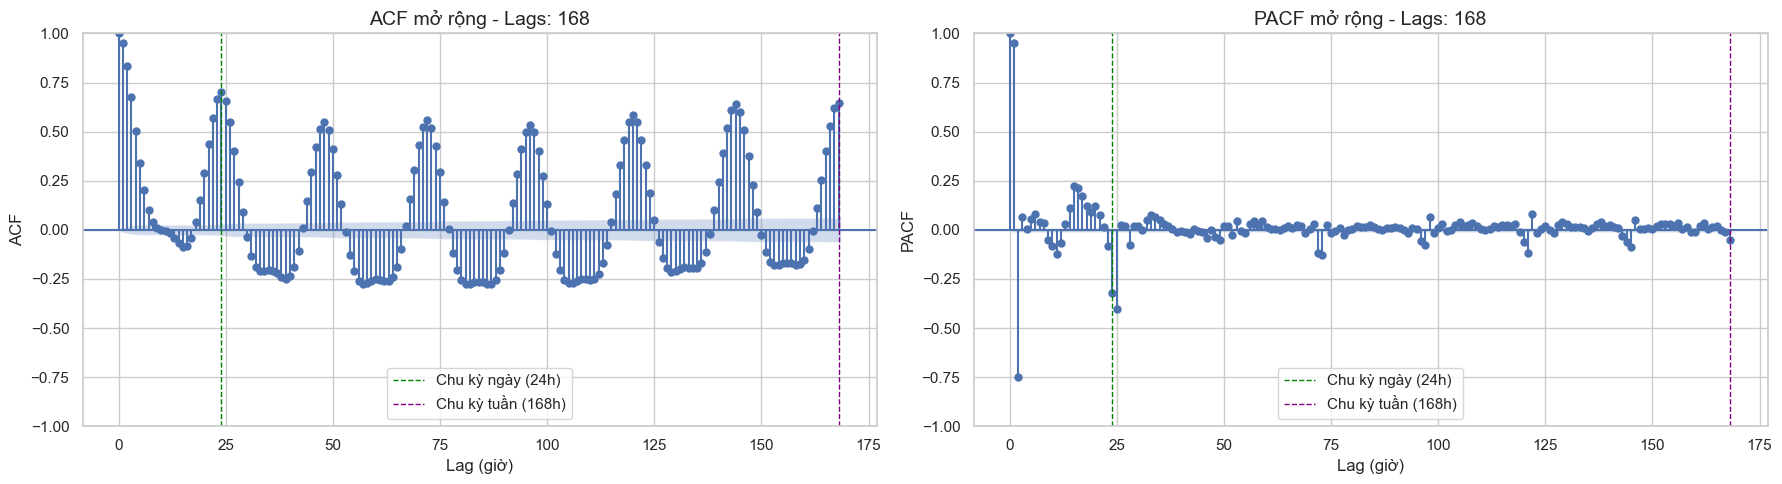

In [9]:
# ACF/PACF mở rộng để kiểm chứng chu kỳ ngày (24h) và tuần (168h)
extended_lag = 168
print(f"Lag mở rộng để kiểm chứng mùa vụ: {extended_lag}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ACF mở rộng
plot_acf(ts, lags=extended_lag, ax=axes[0], alpha=0.05)
axes[0].axvline(24, color='green', linestyle='--', linewidth=1, label='Chu kỳ ngày (24h)')
axes[0].axvline(168, color='purple', linestyle='--', linewidth=1, label='Chu kỳ tuần (168h)')
axes[0].set_title(f'ACF mở rộng - Lags: {extended_lag}')
axes[0].set_xlabel('Lag (giờ)')
axes[0].set_ylabel('ACF')
axes[0].legend()

# PACF mở rộng
plot_pacf(ts, lags=extended_lag, ax=axes[1], alpha=0.05, method='ywm')
axes[1].axvline(24, color='green', linestyle='--', linewidth=1, label='Chu kỳ ngày (24h)')
axes[1].axvline(168, color='purple', linestyle='--', linewidth=1, label='Chu kỳ tuần (168h)')
axes[1].set_title(f'PACF mở rộng - Lags: {extended_lag}')
axes[1].set_xlabel('Lag (giờ)')
axes[1].set_ylabel('PACF')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Nhận xét biểu đồ ACF và PACF

Dựa trên biểu đồ ACF và PACF, mặc dù công thức thực nghiệm $\min(10 \log_{10} n, n/5)$ chỉ đề xuất lag tối đa khoảng 45, nhóm đã chủ động mở rộng quan sát lên 168 lags (tương đương 1 tuần) để rút ra các kết luận toàn diện về cấu trúc của chuỗi thời gian `total load actual`:

**1. Phân tích hàm tự tương quan (ACF - Autocorrelation Function):**
* **Suy giảm chậm:** Các hệ số tự tương quan giảm rất chậm theo lag và duy trì mức ý nghĩa thống kê ở khoảng cách xa. Đây là dấu hiệu kinh điển xác nhận một **chuỗi không dừng (non-stationary)**. 
* **Cấu trúc dao động hình sin (sinusoidal):** Biểu đồ ACF có dạng sóng hình sin rõ rệt. Với cửa sổ 168 lags, các đỉnh dương lặp lại đều đặn tại các bội số của 24 (24, 48, 72..., 168). Điều này cung cấp bằng chứng thống kê vững chắc về sự tồn tại của tính mùa vụ kép: chu kỳ ngày (24h) và chu kỳ tuần (168h).

**2. Phân tích hàm tự tương quan riêng phần (PACF - Partial Autocorrelation Function):**
* **Cut-off ở các lag đầu tiên:** Biểu đồ PACF có các gai (spikes) rất cao (xấp xỉ $1$) ở lag 1 và lag 2, sau đó suy giảm đột ngột ở lag 3 ($-0.75$). Điều này ám chỉ rằng giá trị hiện tại chịu ảnh hưởng trực tiếp và lớn nhất từ 1 đến 2 giờ ngay trước đó => có thể sử dụng thành phần tự hồi quy (AR) bậc 1 hoặc 2 trong mô hình hóa.
* **Gai âm tại lag 24:** Xuất hiện các gai có giá trị $\approx -0.4$ tại lag 24. Điều này chứng tỏ sự tồn tại của một thành phần mùa vụ có ảnh hưởng đáng kể đến giá trị hiện tại.

**3. Kết luận hướng tiếp cận cho tiền xử lý:**
* **Feature engineering:** Căn cứ vào PACF, khi xây dựng ma trận đặc trưng cho dự báo, ta cần bắt buộc tạo các biến trễ (lag features) ngắn hạn quan trọng lag $t-1, t-2$ và các lag có giá trị tương quan âm mạnh tại $t-3$ và đặc biệt là $t-24$ để nắm bắt được ảnh hưởng của chu kỳ ngày.

### c) Thống kê trượt (Rolling statistics)
Tính toán và trực quan hóa trung bình trượt, độ lệch chuẩn trượt với cửa sổ 7, 30 và 90 ngày. Từ đó đưa ra nhận xét về tính dừng sơ bộ của chuỗi.

Do dữ liệu có tần suất theo giờ (hourly), ta sẽ quy đổi các khung thời gian tương ứng:
- 7 ngày = $7 \times 24 = 168$ giờ
- 30 ngày = $30 \times 24 = 720$ giờ
- 90 ngày = $90 \times 24 = 2160$ giờ

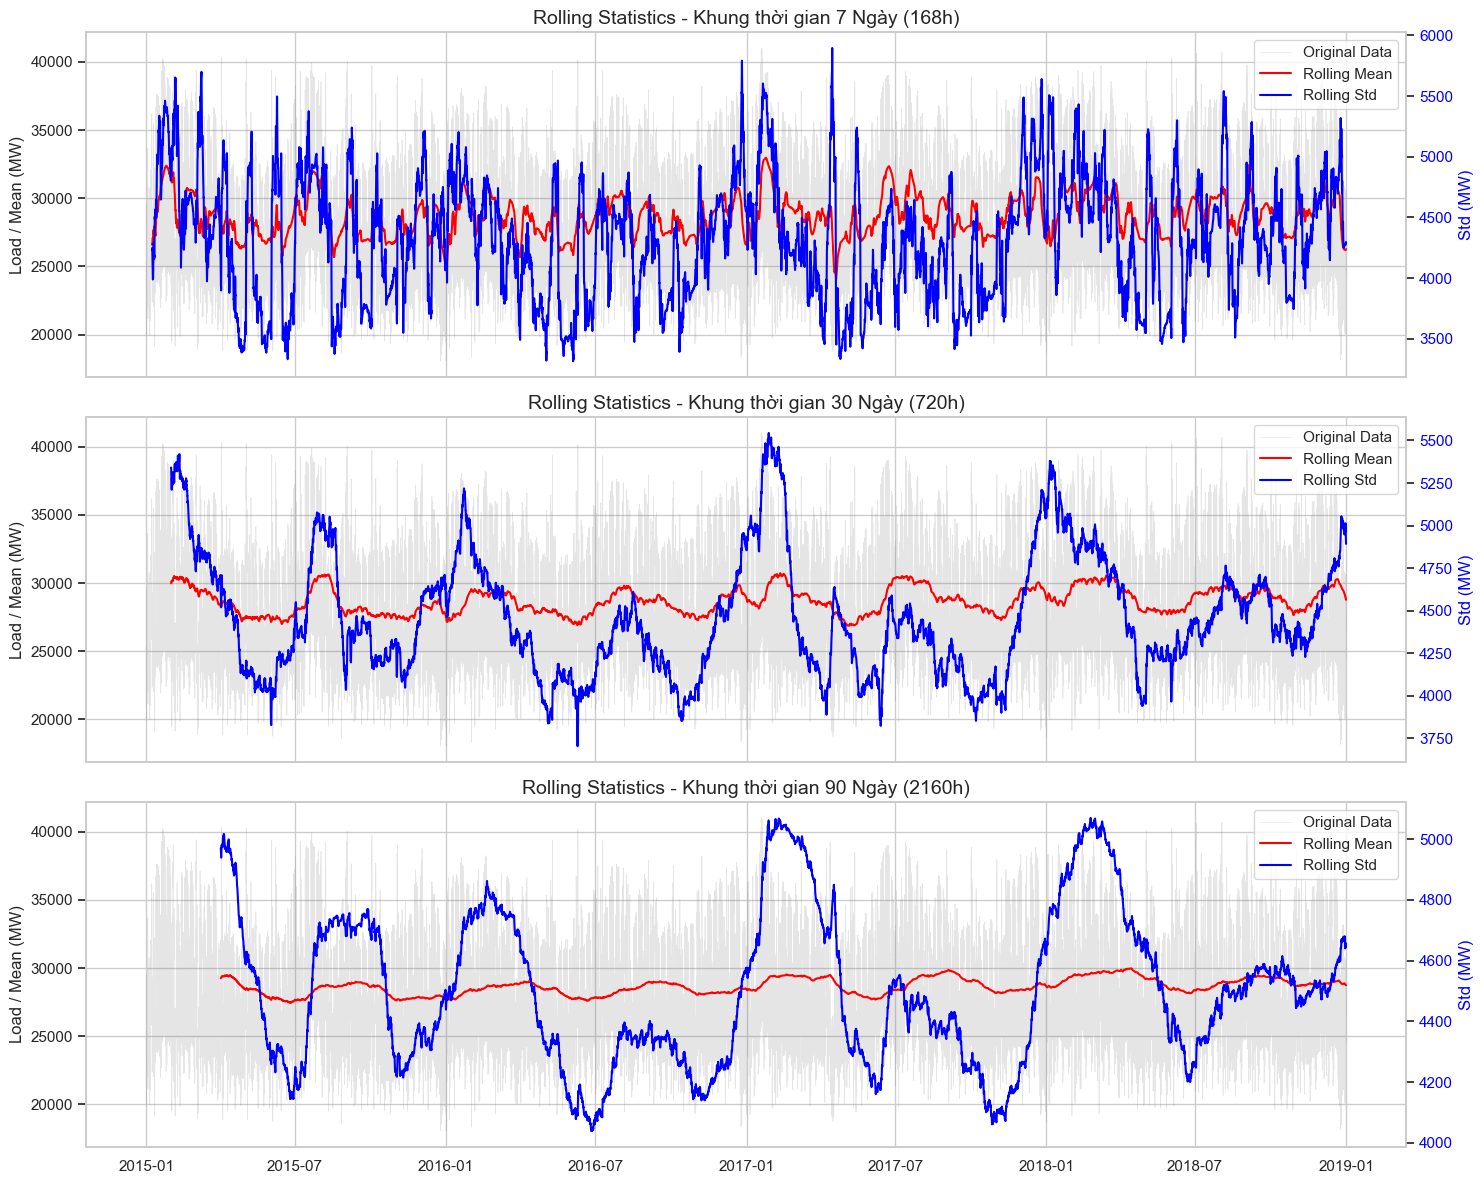

In [10]:
windows = {
    '7 Ngày (168h)': 168,
    '30 Ngày (720h)': 720,
    '90 Ngày (2160h)': 2160
}

fig, axes = plt.subplots(len(windows), 1, figsize=(15, 12), sharex=True)

for ax, (label, window) in zip(axes, windows.items()):
    rolling_mean = ts.rolling(window=window).mean()
    rolling_std = ts.rolling(window=window).std()

    # Trục trái: dữ liệu gốc và rolling mean
    line_original, = ax.plot(ts.index, ts.values, label='Original Data', alpha=0.2, color='gray', linewidth=0.5)
    line_mean, = ax.plot(rolling_mean.index, rolling_mean, label='Rolling Mean', color='red', linewidth=1.5)
    ax.set_ylabel('Load / Mean (MW)')

    # Trục phải: rolling std để nhìn rõ biến thiên phương sai
    ax_std = ax.twinx()
    ax_std.grid(False) # Tắt grid trên trục phụ để tránh rối mắt
    line_std, = ax_std.plot(rolling_std.index, rolling_std, label='Rolling Std', color='blue', linewidth=1.5)
    ax_std.set_ylabel('Std (MW)', color='blue')
    ax_std.tick_params(axis='y', labelcolor='blue')

    ax.set_title(f'Rolling Statistics - Khung thời gian {label}')

    # Gộp legend từ hai trục
    lines = [line_original, line_mean, line_std]
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, loc='upper right')

plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()

#### Nhận xét về Rolling Mean và Rolling Std

Việc áp dụng kỹ thuật tính toán trung bình trượt (rolling mean) và độ lệch chuẩn trượt (rolling standard deviation) với các cửa sổ thời gian mở rộng dần (7 ngày, 30 ngày, 90 ngày) kết hợp với *trục tung phụ* giúp bóc tách và bộc lộ rõ các đặc tính dài hạn của chuỗi `total load actual`. Dựa trên biểu đồ, ta có các đánh giá sau:

**1. Phân tích rolling mean (đường màu đỏ - trục trái):**
* **Khung 7 ngày (168h):** Đường trung bình đã làm phẳng các nhiễu động chu kỳ ngày/đêm, bám sát xu hướng tiêu thụ vĩ mô của từng tuần.
* **Khung 30 ngày (720h) và 90 ngày (2160h):** Hiệu ứng làm phẳng càng rõ rệt. Đặc biệt ở khung 90 ngày, đường rolling mean bộc lộ rõ bản chất không phải là một đường nằm ngang cố định. Thay vào đó, nó uốn lượn thành các làn sóng vĩ mô theo chu kỳ mùa vụ hàng năm (đạt đỉnh vào các tháng cao điểm như mùa đông/mùa hè và chạm đáy vào các giai đoạn chuyển mùa).
* **Kết luận:** Mean của chuỗi thay đổi liên tục theo thời gian, vi phạm điều kiện đầu tiên của một chuỗi thời gian dừng.

**2. Phân tích rolling std (đường màu xanh dương - trục phải):**
* Việc tách riêng thang đo cho độ lệch chuẩn giúp ta quan sát rõ sự biến thiên của phương sai. Ở khung 7 ngày, rolling std dao động liên tục với biên độ lớn (từ 3000 đến hơn 6000 MW), phản ánh độ lệch pha tiêu thụ điện năng mạnh giữa ngày làm việc và ngày nghỉ, ngày lễ.
* Khi mở rộng lên khung 90 ngày, đường rolling std vẫn tạo thành một đường sin dao động(chủ yếu trong khoảng 4000 - 5200 MW). Phương sai có xu hướng phình to ở các giai đoạn tiêu thụ cao điểm và hẹp lại ở vùng đáy. Điều này chứng minh chuỗi mắc phải hiện tượng *phương sai thay đổi theo thời gian*

**3. Đánh giá tính dừng và hướng xử lý:**
* Theo định nghĩa thống kê, một chuỗi thời gian là chuỗi dừng khi và chỉ khi mean và phương sai của nó là hằng số theo thời gian.
* Qua biểu đồ trực quan, cả kỳ vọng và phương sai đều biến thiên có chu kỳ. Do đó, ta có đủ cơ sở để kết luận đây là một **chuỗi không dừng (non-stationary)**  
* **Hướng xử lý tiếp theo:** Phát hiện quan trọng này là tiền đề bắt buộc để nhóm áp dụng các phép biến đổi ổn định phương sai (như Log Transform hoặc Box-Cox) và ổn định trung bình (Differencing hoặc phân rã chuỗi bằng STL decomposition) trước khi đưa dữ liệu vào các kiểm định nghiệm đơn vị (Unit root test) và mô hình dự báo.